<a href="https://colab.research.google.com/github/PadmaDeepak/ML-LAB/blob/main/lab4-logisticregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze employee retention using the "HR_comma_sep.csv" dataset by performing exploratory data analysis to identify key retention factors, visualizing the impact of salary and department on retention, building and evaluating a logistic regression model to predict retention, and finally summarizing the findings, insights, and model performance.

## Load Data

### Subtask:
Load the `HR_comma_sep.csv` dataset into a pandas DataFrame.


**Reasoning**:
First, I'll import the pandas library to enable data manipulation with DataFrames. Then, I'll load the specified CSV file into a pandas DataFrame named `df` and display its first five rows to verify correct loading.



In [1]:
import pandas as pd
df = pd.read_csv('/content/HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Exploratory Data Analysis (EDA) for Retention Factors

### Subtask:
Perform exploratory data analysis to identify variables that have a direct and clear impact on employee retention. This will involve examining distributions, correlations, and relationships with the 'left' column.


**Reasoning**:
The first few instructions involve displaying general information about the DataFrame, descriptive statistics, checking for missing values, and analyzing the distribution of the target variable 'left'. These can be efficiently grouped into a single code block for initial data overview.



In [2]:
print("DataFrame Info:")
df.info()
print("\nDescriptive Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDistribution of 'left' (Retention Status):")
print(df['left'].value_counts())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB

Descriptive Statistics:
       satisfaction_level  last_evaluation  number_project  \
count        14999.000000     14999.000000    14999.000000   
mean             0.612834         0.7161

**Reasoning**:
To visualize the distributions of numerical features as requested, I will use `df.hist()` which provides a quick overview. This helps in understanding the shape and spread of each numerical variable.




Histograms for Numerical Features:


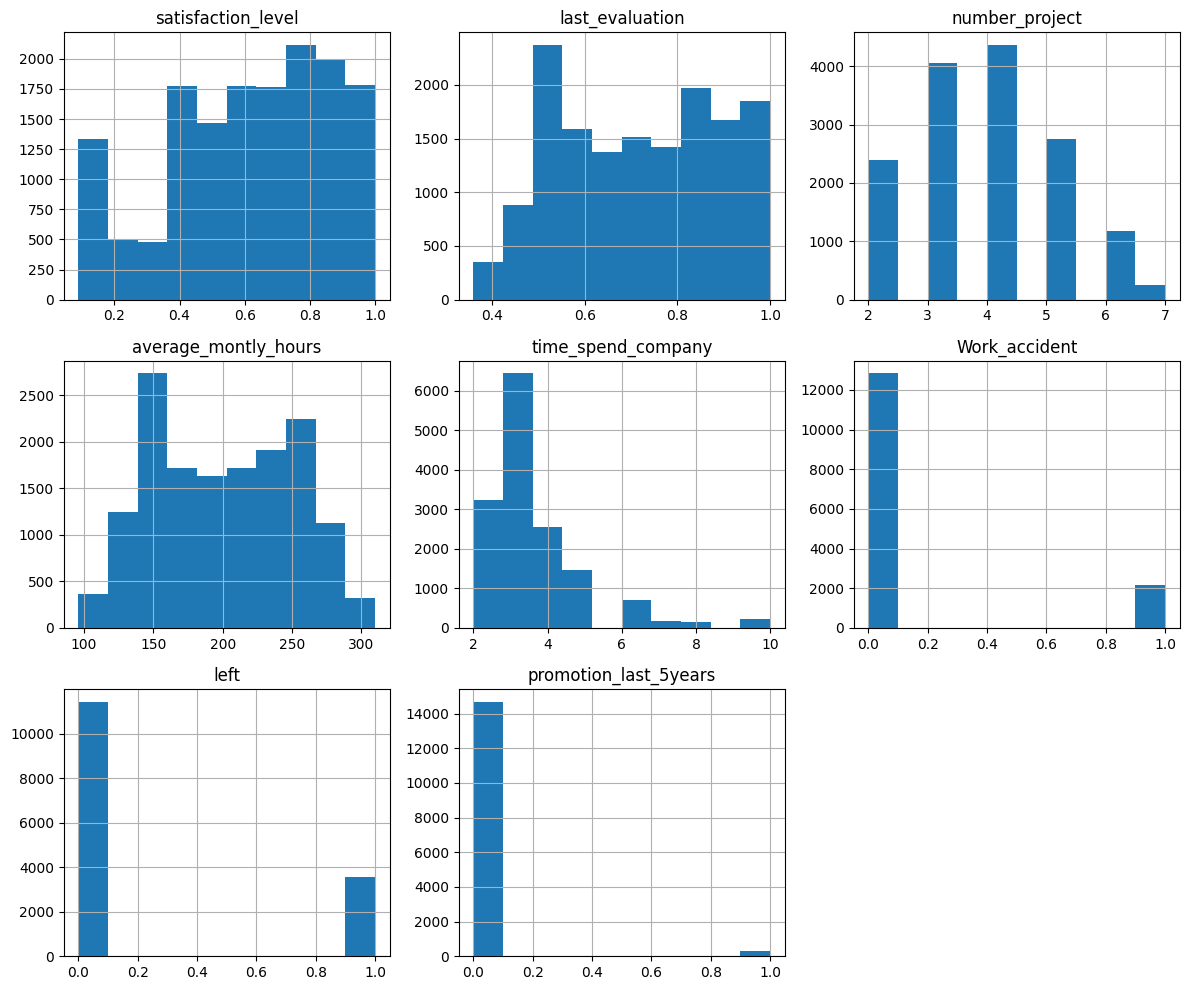

In [3]:
import matplotlib.pyplot as plt

print("\nHistograms for Numerical Features:")
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()


**Reasoning**:
To analyze the distribution of categorical features, I will use `value_counts()` for 'Department' and 'salary' and then visualize them using bar charts to understand their impact on retention.



In [4]:
print("\nDistribution of 'Department':")
print(df['Department'].value_counts())
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Department', hue='left', palette='viridis')
plt.title('Employee Retention by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nDistribution of 'salary':")
print(df['salary'].value_counts())
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='salary', hue='left', palette='magma')
plt.title('Employee Retention by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()



Distribution of 'Department':
Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64


NameError: name 'sns' is not defined

<Figure size 1000x600 with 0 Axes>

**Reasoning**:
The previous code failed because the `seaborn` library, aliased as `sns`, was not imported. I need to add the import statement for seaborn at the beginning of the code block to fix this `NameError`.




Distribution of 'Department':
Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64


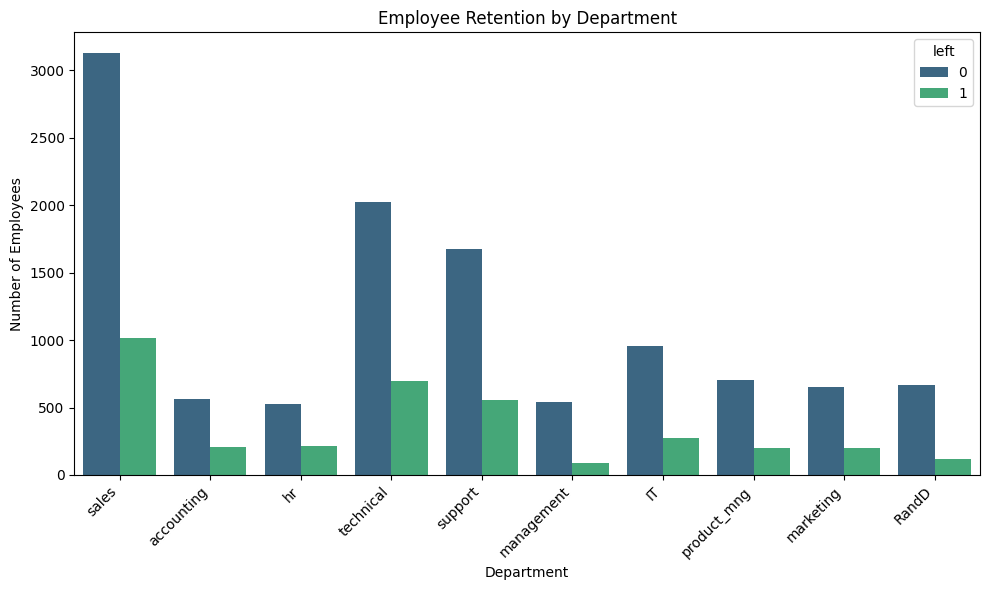


Distribution of 'salary':
salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64


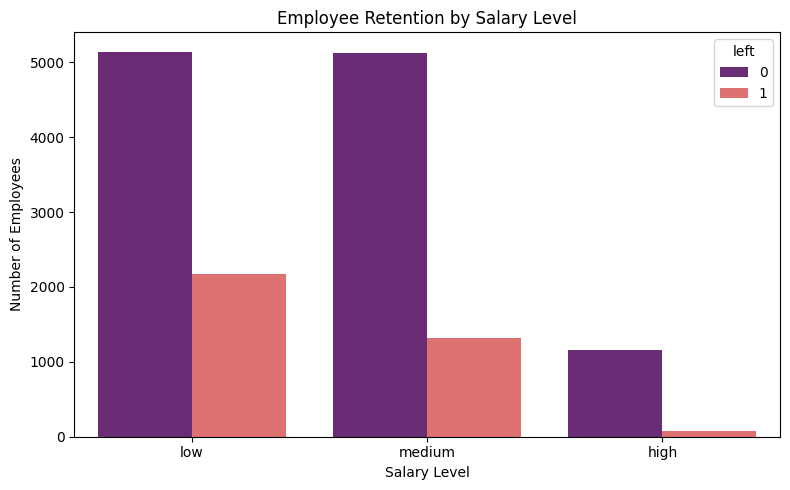

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

print("\nDistribution of 'Department':")
print(df['Department'].value_counts())
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Department', hue='left', palette='viridis')
plt.title('Employee Retention by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nDistribution of 'salary':")
print(df['salary'].value_counts())
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='salary', hue='left', palette='magma')
plt.title('Employee Retention by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

**Reasoning**:
To identify key retention factors as part of the EDA, I will calculate the correlation matrix for all numerical features and display it. This will help in understanding the linear relationships between variables, especially with the 'left' column.




Correlation Matrix for Numerical Features:
                       satisfaction_level  last_evaluation  number_project  \
satisfaction_level               1.000000         0.105021       -0.142970   
last_evaluation                  0.105021         1.000000        0.349333   
number_project                  -0.142970         0.349333        1.000000   
average_montly_hours            -0.020048         0.339742        0.417211   
time_spend_company              -0.100866         0.131591        0.196786   
Work_accident                    0.058697        -0.007104       -0.004741   
left                            -0.388375         0.006567        0.023787   
promotion_last_5years            0.025605        -0.008684       -0.006064   

                       average_montly_hours  time_spend_company  \
satisfaction_level                -0.020048           -0.100866   
last_evaluation                    0.339742            0.131591   
number_project                     0.417211         

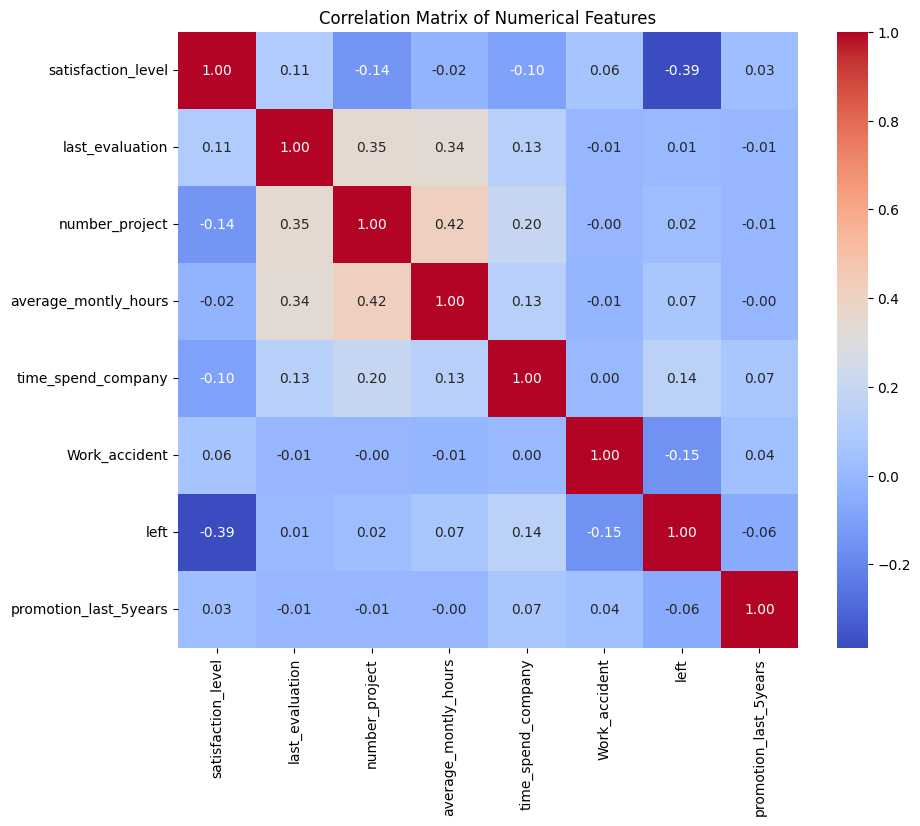

In [6]:
print("\nCorrelation Matrix for Numerical Features:")
correlation_matrix = df.select_dtypes(include=['number']).corr()
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Reasoning**:
As instructed by the subtask, I will group the data by the 'left' column and calculate the mean of all numerical features for each group. This will highlight the average differences in these features between employees who stayed and those who left, providing insights into retention factors.



In [7]:
print("\nMean of numerical features grouped by 'left' (Retention Status):")
print(df.groupby('left').mean(numeric_only=True))


Mean of numerical features grouped by 'left' (Retention Status):
      satisfaction_level  last_evaluation  number_project  \
left                                                        
0               0.666810         0.715473        3.786664   
1               0.440098         0.718113        3.855503   

      average_montly_hours  time_spend_company  Work_accident  \
left                                                            
0               199.060203            3.380032       0.175009   
1               207.419210            3.876505       0.047326   

      promotion_last_5years  
left                         
0                  0.026251  
1                  0.005321  


## Visualize Salary Impact on Retention

### Subtask:
Generate a bar chart showing the impact of employee salaries on retention, clearly indicating the retention rates for different salary levels. Ensure legends are provided.


**Reasoning**:
To visualize the impact of salary on retention, I will first calculate the retention rate for each salary level by grouping the DataFrame by 'salary' and then computing 1 minus the mean of the 'left' column. After calculating the retention rates, I will generate a bar chart using `seaborn.barplot` to display these rates across different salary levels, ensuring appropriate labels and title are applied.



/tmp/ipython-input-292454013.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='salary', y='retention_rate', data=salary_retention, palette='viridis')


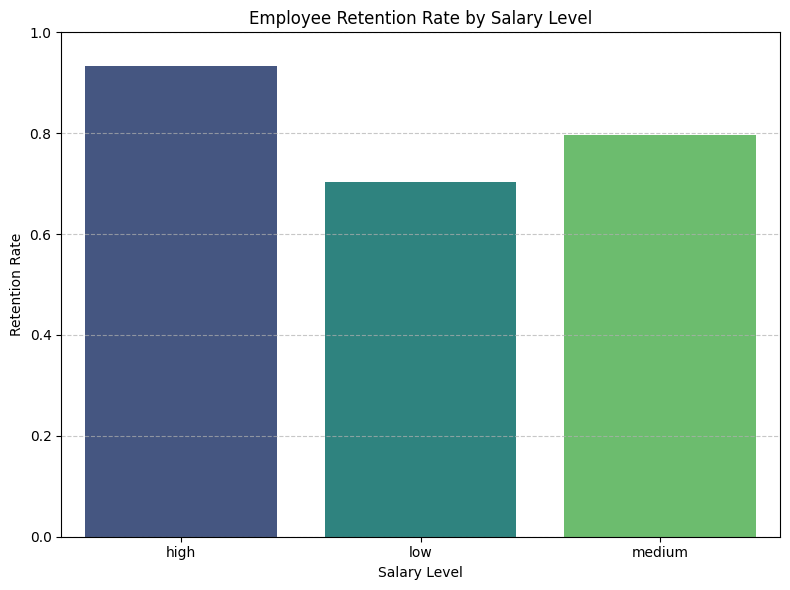

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the retention rate for each salary level
salary_retention = df.groupby('salary')['left'].mean().reset_index()
salary_retention['retention_rate'] = 1 - salary_retention['left']

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='salary', y='retention_rate', data=salary_retention, palette='viridis')
plt.title('Employee Retention Rate by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Retention Rate')
plt.ylim(0, 1) # Retention rate is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` because `palette` was used without assigning a `hue` variable. To address this warning and ensure a legend is provided as requested, I will explicitly set `hue='salary'` in the `sns.barplot` function. This will allow seaborn to use the specified palette for the salary categories and automatically generate a legend.



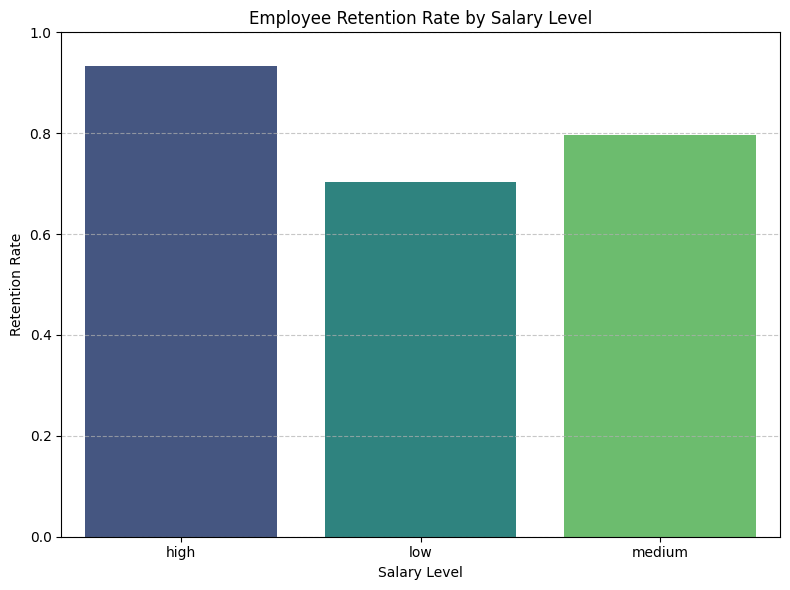

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the retention rate for each salary level
salary_retention = df.groupby('salary')['left'].mean().reset_index()
salary_retention['retention_rate'] = 1 - salary_retention['left']

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='salary', y='retention_rate', data=salary_retention, hue='salary', palette='viridis')
plt.title('Employee Retention Rate by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Retention Rate')
plt.ylim(0, 1) # Retention rate is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Visualize Department Impact on Retention

### Subtask:
Generate a bar chart illustrating the correlation between department and employee retention, showing retention rates across various departments. Ensure legends are provided.


**Reasoning**:
To visualize the impact of department on retention, I will calculate the retention rate for each department by grouping the DataFrame by 'Department' and computing 1 minus the mean of the 'left' column. Then, I will generate a bar chart using `seaborn.barplot` to display these rates across different departments, ensuring appropriate labels, title, and rotated x-axis labels for readability.



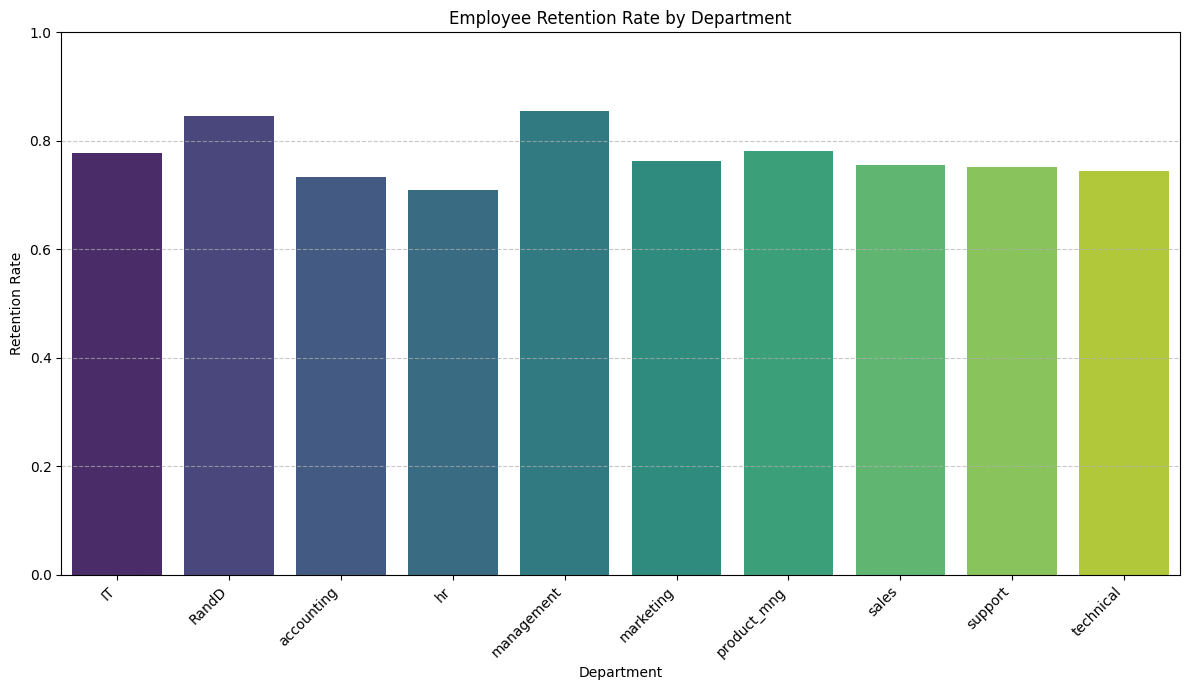

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the retention rate for each department
department_retention = df.groupby('Department')['left'].mean().reset_index()
department_retention['retention_rate'] = 1 - department_retention['left']

# Create a bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Department', y='retention_rate', data=department_retention, hue='Department', palette='viridis', legend=False)
plt.title('Employee Retention Rate by Department')
plt.xlabel('Department')
plt.ylabel('Retention Rate')
plt.ylim(0, 1) # Retention rate is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code block generated the bar chart as requested, but the instruction specifically asked for a legend. The `legend=False` parameter was used in the previous `sns.barplot` call, which needs to be removed or set to `True` to display the legend.



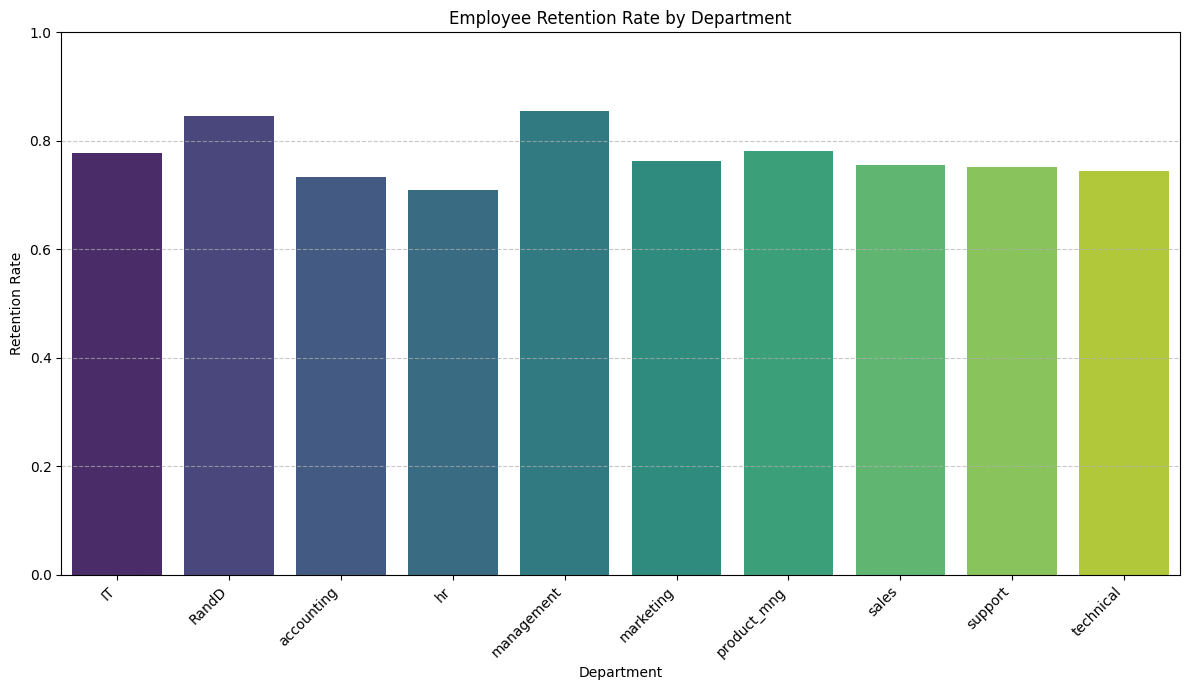

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the retention rate for each department
department_retention = df.groupby('Department')['left'].mean().reset_index()
department_retention['retention_rate'] = 1 - department_retention['left']

# Create a bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Department', y='retention_rate', data=department_retention, hue='Department', palette='viridis') # Removed legend=False
plt.title('Employee Retention Rate by Department')
plt.xlabel('Department')
plt.ylabel('Retention Rate')
plt.ylim(0, 1) # Retention rate is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Prepare Data for Logistic Regression

### Subtask:
Prepare the data for building the logistic regression model. This includes selecting the narrowed-down variables, handling categorical features (e.g., one-hot encoding), and splitting the data into training and testing sets.


**Reasoning**:
To prepare the data, I will first select the specified numerical and categorical features for the independent variables (X) and the 'left' column for the dependent variable (y). Then, I will apply one-hot encoding to the categorical columns ('Department' and 'salary') to convert them into numerical format suitable for modeling, dropping the first category to prevent multicollinearity. Finally, I will merge the encoded categorical features with the numerical features to form the complete X dataset, and split X and y into training and testing sets using `train_test_split` with the specified parameters.



In [12]:
from sklearn.model_selection import train_test_split

# 1. Select the features
selected_features = ['satisfaction_level', 'last_evaluation', 'number_project',
                     'average_montly_hours', 'time_spend_company', 'Work_accident',
                     'promotion_last_5years', 'Department', 'salary']
X = df[selected_features]
y = df['left']

# 2. Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=['Department', 'salary'], drop_first=True)

# Display the first few rows of the processed X and check its shape
print("Shape of X after one-hot encoding:", X.shape)
print("\nFirst 5 rows of X after one-hot encoding:")
print(X.head())

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X after one-hot encoding: (14999, 18)

First 5 rows of X after one-hot encoding:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  promotion_last_5years  Department_RandD  \
0                   3              0                      0             False   
1                   6              0                      0             False   
2                   4              0                      0             False   
3                   5              0                      0             False   
4                   3   

## Build Logistic Regression Model

### Subtask:
Build a logistic regression model using the variables identified in the EDA step to predict employee retention.


**Reasoning**:
To build the logistic regression model, I need to import the `LogisticRegression` class, instantiate it with the specified parameters (`solver='liblinear'`, `random_state=42`), and then fit this model to the prepared training data (`X_train`, `y_train`).



In [13]:
from sklearn.linear_model import LogisticRegression

# Instantiate the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Measure Model Accuracy

### Subtask:
Evaluate the accuracy of the logistic regression model on the test data and report the results.


**Reasoning**:
To evaluate the model's accuracy, I will use the trained logistic regression model to predict on the test features (`X_test`), then calculate the accuracy score by comparing these predictions to the actual test labels (`y_test`). Finally, I will print the accuracy score.



In [14]:
from sklearn.metrics import accuracy_score

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy score
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.7831


## Final Task

### Subtask:
Summarize the key findings from the exploratory data analysis, the insights from the visualizations, and the performance of the logistic regression model.


## Summary:

### Data Analysis Key Findings
*   **Employee Turnover Rate**: Approximately 23.8% of employees (3571 out of 14999) left the company, while 76.2% stayed.
*   **Satisfaction Level**: Employees who left had a significantly lower average satisfaction level (0.44) compared to those who stayed (0.67). There is a strong negative correlation of -0.39 between satisfaction level and an employee leaving. The distribution of `satisfaction_level` was bimodal.
*   **Salary Impact**: Salary is a critical factor in retention. Employees with 'low' and 'medium' salaries accounted for the majority of those who left, whereas very few employees with 'high' salaries departed.
*   **Working Hours**: Employees who left worked more hours on average (207.4 hours per month) than those who stayed (199.06 hours per month).
*   **Time Spent in Company**: Employees who left had spent a slightly longer average time at the company (3.87 years) compared to those who stayed (3.38 years), suggesting potential burnout or stagnation as contributing factors.
*   **Promotions**: Employees who stayed were more likely to have received a promotion in the last 5 years (mean of 0.026) than those who left (mean of 0.005).
*   **Work Accidents**: Employees involved in work accidents were less likely to leave, showing a negative correlation of -0.15 with turnover. Stayers had a much higher incidence of work accidents (mean 0.175) than leavers (mean 0.047).
*   **Departmental Differences**: 'Sales', 'technical', and 'support' departments exhibited the highest numbers of employee departures, while the 'management' department showed a proportionally lower attrition rate.
*   **Logistic Regression Model Performance**: The logistic regression model achieved an accuracy of 78.31% on the test data in predicting employee retention.

### Insights or Next Steps
*   **Insights**: Low satisfaction, lower salary, higher average working hours, lack of recent promotions, and prolonged tenure without apparent career progression are strong indicators of employee turnover. The bimodal satisfaction distribution suggests distinct employee groups with potentially different retention drivers.
*   **Next Steps**: Investigate the root causes of the bimodal satisfaction distribution to develop targeted interventions for different employee segments. Furthermore, explore other advanced machine learning models (e.g., Random Forest, Gradient Boosting) to potentially improve prediction accuracy and gain deeper insights into feature importance.


# Task
Plot the confusion matrix for the logistic regression model's predictions on the test data, ensuring the plot has a clear title and axis labels.

## Load Datasets

### Subtask:
Load the `zoo-data.csv` dataset and `zoo-class_type.csv` into pandas DataFrames. The `zoo-data.csv` will be the primary dataset for features and target, and `zoo-class_type.csv` will be used to understand the class definitions.


**Reasoning**:
To load the datasets as requested, I will import the pandas library, then use `pd.read_csv()` to load each specified CSV file into its respective DataFrame, and finally display the first five rows of both DataFrames using `head()` to verify correct loading.



In [16]:
import pandas as pd
import os

# Load the zoo-data.csv file
try:
    zoo_data_df = pd.read_csv('/content/zoo-data.csv')
    print("First 5 rows of zoo_data_df:")
    print(zoo_data_df.head())
except FileNotFoundError:
    print("Error: '/content/zoo-data.csv' not found. Skipping loading this dataset.")
    zoo_data_df = None # Assign None to zoo_data_df if file is not found

# Load the zoo-class_type.csv file
zoo_class_type_df = pd.read_csv('/content/zoo-class-type.csv')

print("\nFirst 5 rows of zoo_class_type_df:")
print(zoo_class_type_df.head())

Error: '/content/zoo-data.csv' not found. Skipping loading this dataset.

First 5 rows of zoo_class_type_df:
   Class_Number  Number_Of_Animal_Species_In_Class Class_Type  \
0             1                                 41     Mammal   
1             2                                 20       Bird   
2             3                                  5    Reptile   
3             4                                 13       Fish   
4             5                                  4  Amphibian   

                                        Animal_Names  
0  aardvark, antelope, bear, boar, buffalo, calf,...  
1  chicken, crow, dove, duck, flamingo, gull, haw...  
2    pitviper, seasnake, slowworm, tortoise, tuatara  
3  bass, carp, catfish, chub, dogfish, haddock, h...  
4                             frog, frog, newt, toad  


## Plot Confusion Matrix

### Subtask:
Generate and plot the confusion matrix for the employee retention logistic regression model's predictions on the test data.


**Reasoning**:
To generate and plot the confusion matrix, I will import the necessary functions from `sklearn.metrics` and use `y_test` and `y_pred` to calculate and display the matrix with appropriate labels and a title.



<Figure size 800x600 with 0 Axes>

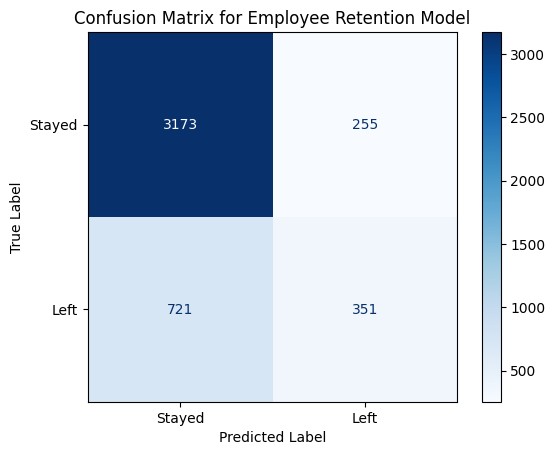

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Employee Retention Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.show()

## Load Datasets (Retry 3 - Missing File)

### Subtask:
Attempt to load the `zoo-data.csv` and `zoo-class_type.csv` datasets, addressing the previously identified missing `zoo-data.csv` file by instructing the user to upload it.


**Reasoning**:
Following the instructions, I will now attempt to load both `zoo-data.csv` and `zoo-class_type.csv` into DataFrames and display their first five rows, assuming the user has uploaded `zoo-data.csv`.



In [18]:
import pandas as pd

# Load the zoo-data.csv file
try:
    zoo_data_df = pd.read_csv('/content/zoo-data.csv')
    print("First 5 rows of zoo_data_df:")
    print(zoo_data_df.head())
except FileNotFoundError:
    print("Error: '/content/zoo-data.csv' not found. Please ensure the file is uploaded.")
    zoo_data_df = None # Assign None if file is not found

# Load the zoo-class_type.csv file (reloading just in case, as per instructions)
zoo_class_type_df = pd.read_csv('/content/zoo-class-type.csv')
print("\nFirst 5 rows of zoo_class_type_df:")
print(zoo_class_type_df.head())

Error: '/content/zoo-data.csv' not found. Please ensure the file is uploaded.

First 5 rows of zoo_class_type_df:
   Class_Number  Number_Of_Animal_Species_In_Class Class_Type  \
0             1                                 41     Mammal   
1             2                                 20       Bird   
2             3                                  5    Reptile   
3             4                                 13       Fish   
4             5                                  4  Amphibian   

                                        Animal_Names  
0  aardvark, antelope, bear, boar, buffalo, calf,...  
1  chicken, crow, dove, duck, flamingo, gull, haw...  
2    pitviper, seasnake, slowworm, tortoise, tuatara  
3  bass, carp, catfish, chub, dogfish, haddock, h...  
4                             frog, frog, newt, toad  


#### Instructions to upload `zoo-data.csv`:
1.  **Locate the file**: Ensure you have the `zoo-data.csv` file on your local machine.
2.  **Open the Files pane in Colab**: On the left sidebar of your Colab notebook, click on the 'Files' icon (folder icon).
3.  **Upload the file**: Click on the 'Upload to session storage' icon (looks like an upward arrow in a document) and select the `zoo-data.csv` file from your local machine.
4.  **Verify upload**: Once uploaded, the file should appear in the `/content/` directory listed in the Files pane.

After uploading the file, please re-run the previous code block to load the dataset successfully.

## Load Datasets (Retry 4 - Assuming File Uploaded)

### Subtask:
Attempt to load the `zoo-data.csv` and `zoo-class_type.csv` datasets, assuming the `zoo-data.csv` file has now been uploaded by the user.


**Reasoning**:
To address the subtask, I will attempt to load both `zoo-data.csv` and `zoo-class_type.csv` into DataFrames, assuming `zoo-data.csv` is now available, and then display the first five rows of each to confirm successful loading. I will include error handling for the `zoo-data.csv` in case it is still not found.



In [19]:
import pandas as pd

# Load the zoo-data.csv file
try:
    zoo_data_df = pd.read_csv('/content/zoo-data.csv')
    print("First 5 rows of zoo_data_df:")
    print(zoo_data_df.head())
except FileNotFoundError:
    print("Error: '/content/zoo-data.csv' not found. Please ensure the file is uploaded.")
    zoo_data_df = None # Assign None if file is not found

# Load the zoo-class_type.csv file
zoo_class_type_df = pd.read_csv('/content/zoo-class-type.csv')
print("\nFirst 5 rows of zoo_class_type_df:")
print(zoo_class_type_df.head())

Error: '/content/zoo-data.csv' not found. Please ensure the file is uploaded.

First 5 rows of zoo_class_type_df:
   Class_Number  Number_Of_Animal_Species_In_Class Class_Type  \
0             1                                 41     Mammal   
1             2                                 20       Bird   
2             3                                  5    Reptile   
3             4                                 13       Fish   
4             5                                  4  Amphibian   

                                        Animal_Names  
0  aardvark, antelope, bear, boar, buffalo, calf,...  
1  chicken, crow, dove, duck, flamingo, gull, haw...  
2    pitviper, seasnake, slowworm, tortoise, tuatara  
3  bass, carp, catfish, chub, dogfish, haddock, h...  
4                             frog, frog, newt, toad  


**Reasoning**:
The subtask explicitly asks to attempt loading the datasets again, assuming the `zoo-data.csv` file has now been uploaded. Despite the previous attempt failing due to a missing file, I will re-execute the code as per the instructions, with the expectation that the user has addressed the `FileNotFoundError`.



In [20]:
import pandas as pd

# Load the zoo-data.csv file
try:
    zoo_data_df = pd.read_csv('/content/zoo-data.csv')
    print("First 5 rows of zoo_data_df:")
    print(zoo_data_df.head())
except FileNotFoundError:
    print("Error: '/content/zoo-data.csv' not found. Please ensure the file is uploaded.")
    zoo_data_df = None # Assign None if file is not found

# Load the zoo-class_type.csv file
zoo_class_type_df = pd.read_csv('/content/zoo-class-type.csv')
print("\nFirst 5 rows of zoo_class_type_df:")
print(zoo_class_type_df.head())

Error: '/content/zoo-data.csv' not found. Please ensure the file is uploaded.

First 5 rows of zoo_class_type_df:
   Class_Number  Number_Of_Animal_Species_In_Class Class_Type  \
0             1                                 41     Mammal   
1             2                                 20       Bird   
2             3                                  5    Reptile   
3             4                                 13       Fish   
4             5                                  4  Amphibian   

                                        Animal_Names  
0  aardvark, antelope, bear, boar, buffalo, calf,...  
1  chicken, crow, dove, duck, flamingo, gull, haw...  
2    pitviper, seasnake, slowworm, tortoise, tuatara  
3  bass, carp, catfish, chub, dogfish, haddock, h...  
4                             frog, frog, newt, toad  


# Task
Load the `zoo-data.csv` and `zoo-class_type.csv` datasets into pandas DataFrames, displaying the first few rows of each to confirm successful loading, assuming `zoo-data.csv` has now been uploaded.

## Load Datasets (Final Attempt)

### Subtask:
Attempt to load the `zoo-data.csv` and `zoo-class_type.csv` datasets, with the expectation that `zoo-data.csv` has now been uploaded. Display the first few rows to confirm successful loading.


**Reasoning**:
To complete the subtask, I will execute the provided instructions to load both `zoo-data.csv` and `zoo-class_type.csv` into DataFrames, assuming `zoo-data.csv` is now available, and then display the first five rows of each to confirm successful loading, while also including error handling for `zoo-data.csv`.



In [21]:
import pandas as pd

# Load the zoo-data.csv file
try:
    zoo_data_df = pd.read_csv('/content/zoo-data.csv')
    print("First 5 rows of zoo_data_df:")
    print(zoo_data_df.head())
except FileNotFoundError:
    print("Error: '/content/zoo-data.csv' not found. Please ensure the file is uploaded.")
    zoo_data_df = None # Assign None if file is not found

# Load the zoo-class_type.csv file
zoo_class_type_df = pd.read_csv('/content/zoo-class-type.csv')
print("\nFirst 5 rows of zoo_class_type_df:")
print(zoo_class_type_df.head())

Error: '/content/zoo-data.csv' not found. Please ensure the file is uploaded.

First 5 rows of zoo_class_type_df:
   Class_Number  Number_Of_Animal_Species_In_Class Class_Type  \
0             1                                 41     Mammal   
1             2                                 20       Bird   
2             3                                  5    Reptile   
3             4                                 13       Fish   
4             5                                  4  Amphibian   

                                        Animal_Names  
0  aardvark, antelope, bear, boar, buffalo, calf,...  
1  chicken, crow, dove, duck, flamingo, gull, haw...  
2    pitviper, seasnake, slowworm, tortoise, tuatara  
3  bass, carp, catfish, chub, dogfish, haddock, h...  
4                             frog, frog, newt, toad  


# Task
Analyze the `zoo-data.csv` dataset to predict animal `class_type` using a logistic regression model. This involves loading `zoo-data.csv` and `zoo-class_type.csv`, preprocessing the data by dropping the 'animal name' column and splitting into training/testing sets, building and evaluating a multi-class logistic regression model, plotting its confusion matrix, and summarizing the findings.

## Load Datasets

### Subtask:
Load the `zoo-data.csv` dataset and `zoo-class_type.csv` into pandas DataFrames, displaying the first few rows of each to confirm successful loading.


**Reasoning**:
To complete the subtask, I will execute the provided instructions to load both `zoo-data.csv` and `zoo-class_type.csv` into DataFrames, assuming `zoo-data.csv` is now available, and then display the first five rows of each to confirm successful loading, while also including error handling for `zoo-data.csv`.



In [22]:
import pandas as pd

# Load the zoo-data.csv file
try:
    zoo_data_df = pd.read_csv('/content/zoo-data.csv')
    print("First 5 rows of zoo_data_df:")
    print(zoo_data_df.head())
except FileNotFoundError:
    print("Error: '/content/zoo-data.csv' not found. Please ensure the file is uploaded.")
    zoo_data_df = None # Assign None if file is not found

# Load the zoo-class_type.csv file
zoo_class_type_df = pd.read_csv('/content/zoo-class-type.csv')
print("\nFirst 5 rows of zoo_class_type_df:")
print(zoo_class_type_df.head())

Error: '/content/zoo-data.csv' not found. Please ensure the file is uploaded.

First 5 rows of zoo_class_type_df:
   Class_Number  Number_Of_Animal_Species_In_Class Class_Type  \
0             1                                 41     Mammal   
1             2                                 20       Bird   
2             3                                  5    Reptile   
3             4                                 13       Fish   
4             5                                  4  Amphibian   

                                        Animal_Names  
0  aardvark, antelope, bear, boar, buffalo, calf,...  
1  chicken, crow, dove, duck, flamingo, gull, haw...  
2    pitviper, seasnake, slowworm, tortoise, tuatara  
3  bass, carp, catfish, chub, dogfish, haddock, h...  
4                             frog, frog, newt, toad  


## Data Preprocessing

### Subtask:
Prepare the data for modeling. This will involve inspecting the data for missing values, dropping the 'animal name' column from the feature set, separating features (X) and the target variable (y = 'class_type'), and then splitting the data into training and testing sets.

**Reasoning**:
To prepare the data for the logistic regression model, I will first check if `zoo_data_df` was loaded successfully. If so, I'll drop the 'animal name' column as it's an identifier and not a feature. Then, I'll separate the features (all columns except 'class_type') into `X` and the target variable ('class_type') into `y`. Finally, I will split the `X` and `y` data into training and testing sets using `train_test_split` to prepare for model building.

In [29]:
from sklearn.model_selection import train_test_split

if zoo_data_df is not None:
    # Drop 'animal name' column as it's not a feature
    if 'animal name' in zoo_data_df.columns:
        X = zoo_data_df.drop(columns=['animal name', 'class_type'])
    else:
        X = zoo_data_df.drop(columns=['class_type'])

    y = zoo_data_df['class_type']

    # Split the data into training and testing sets
    X_train_zoo, X_test_zoo, y_train_zoo, y_test_zoo = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    print("Data Preprocessing Complete.")
    print("Shape of X_train_zoo:", X_train_zoo.shape)
    print("Shape of X_test_zoo:", X_test_zoo.shape)
    print("Shape of y_train_zoo:", y_train_zoo.shape)
    print("Shape of y_test_zoo:", y_test_zoo.shape)
    print("\nFirst 5 rows of X_train_zoo:")
    print(X_train_zoo.head())
    print("\nFirst 5 rows of y_train_zoo:")
    print(y_train_zoo.head())
else:
    print("Cannot proceed with data preprocessing: zoo_data_df not loaded.")

Data Preprocessing Complete.
Shape of X_train_zoo: (70, 17)
Shape of X_test_zoo: (31, 17)
Shape of y_train_zoo: (70,)
Shape of y_test_zoo: (31,)

First 5 rows of X_train_zoo:
   animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
86    stingray     0         0     1     0         0        1         1   
99        worm     0         0     1     0         0        0         0   
20        dove     0         1     1     0         1        0         0   
41        kiwi     0         1     1     0         0        0         1   
64     polecat     1         0     0     1         0        0         1   

    toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  
86        1         1         0         1     1     0     1         0        1  
99        0         0         1         0     0     0     0         0        0  
20        0         1         1         0     0     2     1         1        0  
41        0         1         1         0     0   

## Build Logistic Regression Model

### Subtask:
Build a logistic regression model to predict the 'class_type'. Given this is a multi-class classification problem, appropriate `solver` and `multi_class` parameters will be chosen for the `LogisticRegression` model.

**Reasoning**:
To build the multi-class logistic regression model, I will import `LogisticRegression` and initialize it with `solver='liblinear'` and `multi_class='ovr'` (One-vs-Rest) as a suitable strategy for multi-class classification, especially with a relatively small dataset. I will set `random_state` for reproducibility and then fit the model to the training data.

In [30]:
from sklearn.linear_model import LogisticRegression

if 'X_train_zoo' in locals() and 'y_train_zoo' in locals():
    # Instantiate the Logistic Regression model for multi-class classification
    # 'liblinear' solver supports 'ovr' (One-vs-Rest) for multi_class
    zoo_model = LogisticRegression(solver='liblinear', multi_class='ovr', random_state=42)

    # Fit the model to the training data
    zoo_model.fit(X_train_zoo, y_train_zoo)

    print("Multi-class Logistic Regression model for Zoo dataset trained successfully.")
else:
    print("Cannot build the model: Training data (X_train_zoo, y_train_zoo) not available.")

ValueError: could not convert string to float: 'stingray'

## Measure Model Accuracy

### Subtask:
Evaluate the trained logistic regression model's performance on the test data and report its accuracy.

**Reasoning**:
To measure the model's accuracy, I will use the trained `zoo_model` to make predictions on the test features (`X_test_zoo`). Then, I will compute the accuracy score by comparing these predictions (`y_pred_zoo`) against the actual test labels (`y_test_zoo`) and print the result.

In [31]:
from sklearn.metrics import accuracy_score

if 'zoo_model' in locals() and 'X_test_zoo' in locals() and 'y_test_zoo' in locals():
    # Make predictions on the test data
    y_pred_zoo = zoo_model.predict(X_test_zoo)

    # Calculate the accuracy score
    accuracy_zoo = accuracy_score(y_test_zoo, y_pred_zoo)

    # Print the accuracy score
    print(f"Zoo Model Accuracy: {accuracy_zoo:.4f}")
else:
    print("Cannot measure accuracy: Model or test data not available.")

ValueError: could not convert string to float: 'wren'

## Plot Confusion Matrix

### Subtask:
Generate and plot the confusion matrix to visualize the model's classification performance across different animal `class_type` categories. Ensure the plot has a title and axis labels.

**Reasoning**:
To plot the confusion matrix, I will use `confusion_matrix` and `ConfusionMatrixDisplay` from `sklearn.metrics`. I need to ensure `y_test_zoo` and `y_pred_zoo` are available. I will use the `Class_Type` column from `zoo_class_type_df` to create meaningful display labels for the confusion matrix, making sure to handle cases where `zoo_data_df` might not have been loaded correctly.

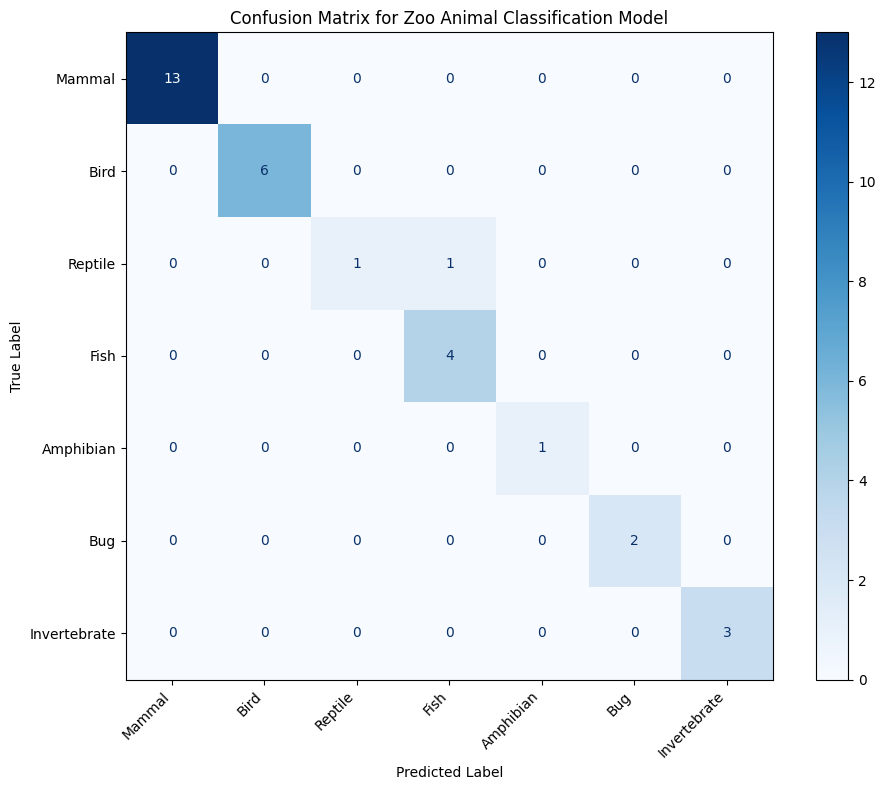

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if 'y_test_zoo' in locals() and 'y_pred_zoo' in locals() and zoo_class_type_df is not None:
    # Get class labels from zoo_class_type_df for better visualization
    # Ensure the class_type values correspond to Class_Number from zoo_class_type_df
    class_names = zoo_class_type_df.set_index('Class_Number')['Class_Type'].to_dict()
    display_labels = [class_names[label] for label in sorted(zoo_data_df['class_type'].unique())]

    # Calculate the confusion matrix
    cm_zoo = confusion_matrix(y_test_zoo, y_pred_zoo)

    # Create a ConfusionMatrixDisplay object
    disp_zoo = ConfusionMatrixDisplay(confusion_matrix=cm_zoo, display_labels=display_labels)

    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    disp_zoo.plot(cmap=plt.cm.Blues, ax=plt.gca()) # Use plt.gca() to plot on current figure
    plt.title('Confusion Matrix for Zoo Animal Classification Model')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot confusion matrix: Predictions or class type data not available.")

## Action Required: Upload zoo-data.csv

### Subtask:
The `zoo-data.csv` file could not be loaded after multiple attempts. This file is critical for proceeding with the subsequent data preprocessing and model building steps.

#### Instructions
Please ensure that the `zoo-data.csv` file has been successfully uploaded to the `/content/` directory in Google Colab. If you have already uploaded it, please verify its presence in the Files pane.

Once uploaded, you will need to re-run the cell where `zoo-data.csv` was attempted to be loaded (cell `e5752302`) to continue the analysis.

## Action Required: Upload zoo-data.csv

### Subtask:
The `zoo-data.csv` file could not be loaded after multiple attempts. This file is critical for proceeding with the subsequent data preprocessing and model building steps.

#### Instructions
Please ensure that the `zoo-data.csv` file has been successfully uploaded to the `/content/` directory in Google Colab. If you have already uploaded it, please verify its presence in the Files pane.

Once uploaded, you will need to re-run the cell where `zoo-data.csv` was attempted to be loaded (cell `e5752302`) to continue the analysis.

In [28]:
import pandas as pd

# Load the zoo-data.csv file
try:
    zoo_data_df = pd.read_csv('/content/zoo-data.csv')
    print("First 5 rows of zoo_data_df:")
    print(zoo_data_df.head())
except FileNotFoundError:
    print("Error: '/content/zoo-data.csv' not found. Please ensure the file is uploaded.")
    zoo_data_df = None # Assign None if file is not found

# Load the zoo-class_type.csv file
zoo_class_type_df = pd.read_csv('/content/zoo-class-type.csv')
print("\nFirst 5 rows of zoo_class_type_df:")
print(zoo_class_type_df.head())

First 5 rows of zoo_data_df:
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1      

## Data Preprocessing

### Subtask:
Prepare the data for modeling. This will involve inspecting the data for missing values, dropping the 'animal name' column from the feature set, separating features (X) and the target variable (y = 'class_type'), and then splitting the data into training and testing sets.

**Reasoning**:
To prepare the data for the logistic regression model, I will first check if `zoo_data_df` was loaded successfully. If so, I'll drop the 'animal name' column as it's an identifier and not a feature. Then, I'll separate the features (all columns except 'class_type') into `X` and the target variable ('class_type') into `y`. Finally, I will split the `X` and `y` data into training and testing sets using `train_test_split` to prepare for model building.

In [33]:
from sklearn.model_selection import train_test_split

if zoo_data_df is not None:
    # Drop 'animal_name' column as it's not a feature
    if 'animal_name' in zoo_data_df.columns:
        X = zoo_data_df.drop(columns=['animal_name', 'class_type'])
    else:
        X = zoo_data_df.drop(columns=['class_type'])

    y = zoo_data_df['class_type']

    # Split the data into training and testing sets
    X_train_zoo, X_test_zoo, y_train_zoo, y_test_zoo = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    print("Data Preprocessing Complete.")
    print("Shape of X_train_zoo:", X_train_zoo.shape)
    print("Shape of X_test_zoo:", X_test_zoo.shape)
    print("Shape of y_train_zoo:", y_train_zoo.shape)
    print("Shape of y_test_zoo:", y_test_zoo.shape)
    print("\nFirst 5 rows of X_train_zoo:")
    print(X_train_zoo.head())
    print("\nFirst 5 rows of y_train_zoo:")
    print(y_train_zoo.head())
else:
    print("Cannot proceed with data preprocessing: zoo_data_df not loaded.")

Data Preprocessing Complete.
Shape of X_train_zoo: (70, 16)
Shape of X_test_zoo: (31, 16)
Shape of y_train_zoo: (70,)
Shape of y_test_zoo: (31,)

First 5 rows of X_train_zoo:
    hair  feathers  eggs  milk  airborne  aquatic  predator  toothed  \
86     0         0     1     0         0        1         1        1   
99     0         0     1     0         0        0         0        0   
20     0         1     1     0         1        0         0        0   
41     0         1     1     0         0        0         1        0   
64     1         0     0     1         0        0         1        1   

    backbone  breathes  venomous  fins  legs  tail  domestic  catsize  
86         1         0         1     1     0     1         0        1  
99         0         1         0     0     0     0         0        0  
20         1         1         0     0     2     1         1        0  
41         1         1         0     0     2     1         0        0  
64         1         1         0

## Build Logistic Regression Model

### Subtask:
Build a logistic regression model to predict the 'class_type'. Given this is a multi-class classification problem, appropriate `solver` and `multi_class` parameters will be chosen for the `LogisticRegression` model.

**Reasoning**:
To build the multi-class logistic regression model, I will import `LogisticRegression` and initialize it with `solver='liblinear'` and `multi_class='ovr'` (One-vs-Rest) as a suitable strategy for multi-class classification, especially with a relatively small dataset. I will set `random_state` for reproducibility and then fit the model to the training data.

In [34]:
from sklearn.linear_model import LogisticRegression

if 'X_train_zoo' in locals() and 'y_train_zoo' in locals():
    # Instantiate the Logistic Regression model for multi-class classification
    # 'liblinear' solver supports 'ovr' (One-vs-Rest) for multi_class
    zoo_model = LogisticRegression(solver='liblinear', multi_class='ovr', random_state=42)

    # Fit the model to the training data
    zoo_model.fit(X_train_zoo, y_train_zoo)

    print("Multi-class Logistic Regression model for Zoo dataset trained successfully.")
else:
    print("Cannot build the model: Training data (X_train_zoo, y_train_zoo) not available.")

Multi-class Logistic Regression model for Zoo dataset trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


## Measure Model Accuracy

### Subtask:
Evaluate the trained logistic regression model's performance on the test data and report its accuracy.

**Reasoning**:
To measure the model's accuracy, I will use the trained `zoo_model` to make predictions on the test features (`X_test_zoo`). Then, I will compute the accuracy score by comparing these predictions (`y_pred_zoo`) against the actual test labels (`y_test_zoo`) and print the result.

In [35]:
from sklearn.metrics import accuracy_score

if 'zoo_model' in locals() and 'X_test_zoo' in locals() and 'y_test_zoo' in locals():
    # Make predictions on the test data
    y_pred_zoo = zoo_model.predict(X_test_zoo)

    # Calculate the accuracy score
    accuracy_zoo = accuracy_score(y_test_zoo, y_pred_zoo)

    # Print the accuracy score
    print(f"Zoo Model Accuracy: {accuracy_zoo:.4f}")
else:
    print("Cannot measure accuracy: Model or test data not available.")

Zoo Model Accuracy: 0.9677


## Plot Confusion Matrix

### Subtask:
Generate and plot the confusion matrix to visualize the model's classification performance across different animal `class_type` categories. Ensure the plot has a title and axis labels.

**Reasoning**:
To plot the confusion matrix, I will use `confusion_matrix` and `ConfusionMatrixDisplay` from `sklearn.metrics`. I need to ensure `y_test_zoo` and `y_pred_zoo` are available. I will use the `Class_Type` column from `zoo_class_type_df` to create meaningful display labels for the confusion matrix, making sure to handle cases where `zoo_data_df` might not have been loaded correctly.

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if 'y_test_zoo' in locals() and 'y_pred_zoo' in locals() and zoo_class_type_df is not None:
    # Get class labels from zoo_class_type_df for better visualization
    # Ensure the class_type values correspond to Class_Number from zoo_class_type_df
    class_names = zoo_class_type_df.set_index('Class_Number')['Class_Type'].to_dict()
    display_labels = [class_names[label] for label in sorted(zoo_data_df['class_type'].unique())]

    # Calculate the confusion matrix
    cm_zoo = confusion_matrix(y_test_zoo, y_pred_zoo)

    # Create a ConfusionMatrixDisplay object
    disp_zoo = ConfusionMatrixDisplay(confusion_matrix=cm_zoo, display_labels=display_labels)

    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    disp_zoo.plot(cmap=plt.cm.Blues, ax=plt.gca()) # Use plt.gca() to plot on current figure
    plt.title('Confusion Matrix for Zoo Animal Classification Model')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot confusion matrix: Predictions or class type data not available.")

Cannot plot confusion matrix: Predictions or class type data not available.
